In [34]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import sobel


In [35]:
import glob

dataset_path = "/content/drive/MyDrive/train"
files = glob.glob(dataset_path + "/*.jpg")
print("the number of the files:", len(files))

the number of the files: 200


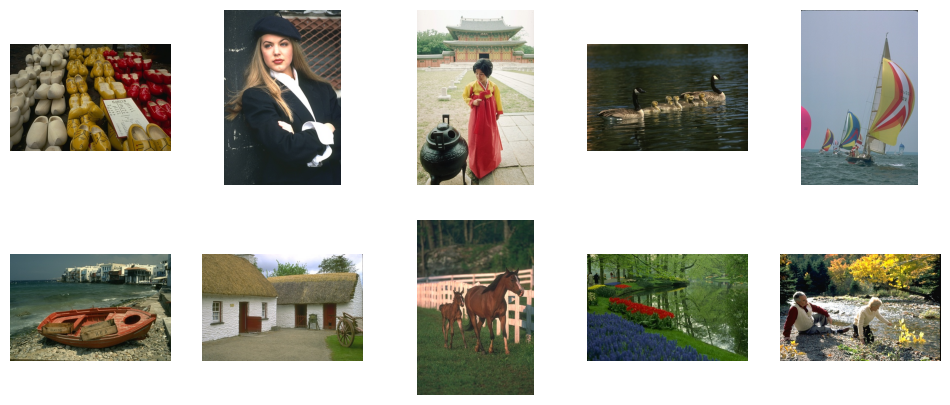

In [36]:
plt.figure(figsize=(12,5))

for i in range(10):
  img = cv2.imread(files[i])
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.subplot(2, 5, i+1)
  plt.imshow(img)
  plt.axis("off")

In [37]:
import os

base = "/content/drive/MyDrive/train"

print("Exists:", os.path.exists(base))
print("Contents:")
print(os.listdir(base))

Exists: True
Contents:
['198054.mat', '188091.mat', '246053.mat', '323016.mat', '23025.mat', '43083.mat', '326038.mat', '236017.mat', '232038.mat', '126039.mat', '106025.mat', '60079.mat', '189011.mat', '140075.mat', '372047.mat', '15088.mat', '28096.mat', '286092.mat', '46076.mat', '187083.mat', '67079.mat', '159029.mat', '135037.mat', '35008.mat', '112082.mat', '163014.mat', '299091.mat', '106020.mat', '108041.mat', '24063.mat', '163062.mat', '216041.mat', '207056.mat', '188005.mat', '56028.mat', '301007.mat', '145053.mat', '153093.mat', '122048.mat', '176039.mat', '178054.mat', '23084.mat', '24004.mat', '385028.mat', '271031.mat', '147021.mat', '374067.mat', '15004.mat', '302003.mat', '161062.mat', '33066.mat', '138032.mat', '22090.mat', '173036.mat', '28075.mat', '92059.mat', '196015.mat', '117054.mat', '268002.mat', '12003.mat', '78019.mat', '247085.mat', '254033.mat', '42078.mat', '370036.mat', '140055.mat', '65010.mat', '71046.mat', '274007.mat', '65019.mat', '66039.mat', '18702

In [38]:
import os

image_root = "/content/drive/MyDrive/train"
image_list = []

for root, dirs, files in os.walk(image_root):
    for file in files:
        if file.lower().endswith(".jpg"):
            image_list.append(os.path.join(root, file))


print("Number of images:", len(image_list))
if len(image_list) > 0:
    print("First image path:", image_list[0])
else:
    print("No images found. Check the folder path again.")

Number of images: 200
First image path: /content/drive/MyDrive/train/140075.jpg


Image shape: (321, 481)


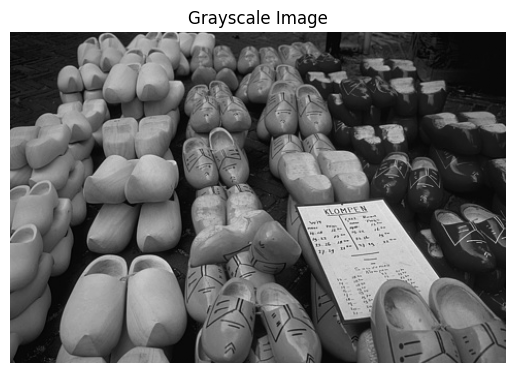

In [39]:
img = Image.open(image_list[0]).convert("L")
img_array = np.array(img)

print("Image shape:", img_array.shape)

plt.imshow(img_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


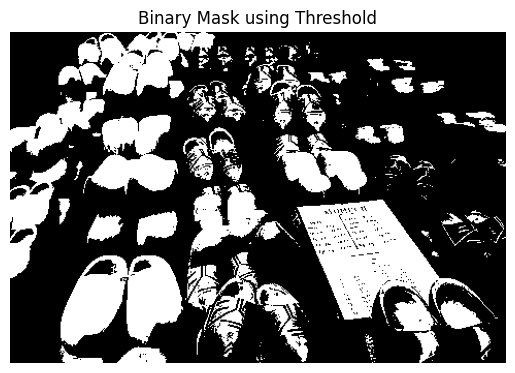

In [23]:
T = 120   # threshold value

mask = (img_array > T).astype(np.uint8)

plt.imshow(mask, cmap="gray")
plt.title("Binary Mask using Threshold")
plt.axis("off")
plt.show()

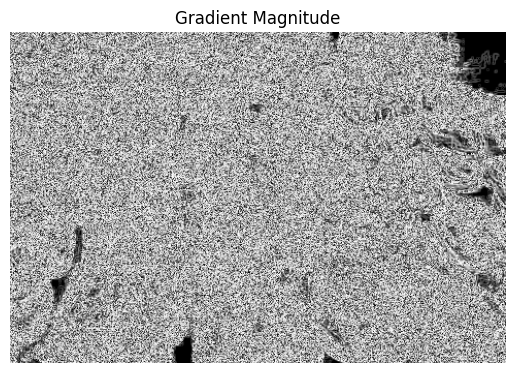

In [24]:
Gx = sobel(img_array, axis=1)   # horizontal gradient
Gy = sobel(img_array, axis=0)   # vertical gradient

gradient_magnitude = np.sqrt(Gx**2 + Gy**2)

plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")
plt.show()

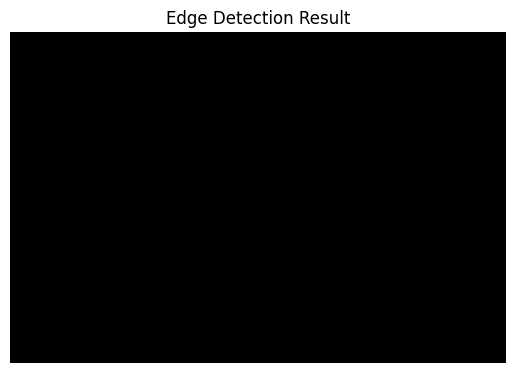

In [25]:
Te = 80   # edge threshold

edges = (gradient_magnitude > Te).astype(np.uint8)

plt.imshow(edges, cmap="gray")
plt.title("Edge Detection Result")
plt.axis("off")
plt.show()

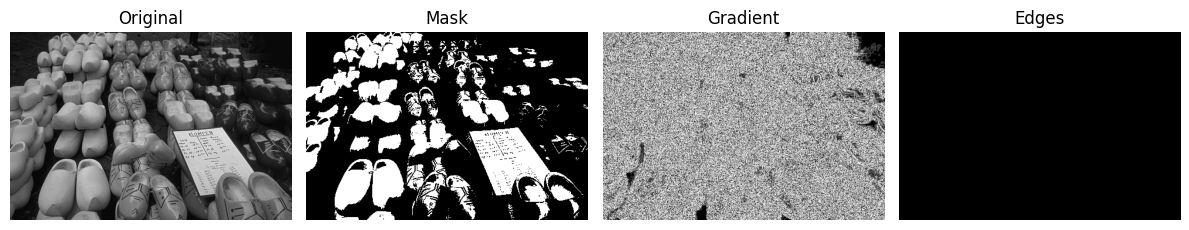

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img_array, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
image_list = []

for root, dirs, files in os.walk(image_root):
    for file in files:
        if file.lower().endswith(".jpg"):
            image_list.append(os.path.join(root, file))

image_list = sorted(image_list)

print("Total images found:", len(image_list))
print("Example:", image_list[0])

Total images found: 200
Example: /content/drive/MyDrive/train/100075.jpg


In [28]:
mask_folder = os.path.join(image_root, "generated_masks_New")
os.makedirs(mask_folder, exist_ok=True)

print("Masks will be saved in:", mask_folder)

Masks will be saved in: /content/drive/MyDrive/train/generated_masks_New


In [29]:
T = 120
print("Using threshold:", T)

Using threshold: 120


In [30]:
for img_path in image_list:
    # Load image and convert to grayscale
    img = Image.open(img_path).convert("L")
    img_array = np.array(img)

    # Threshold-based mask generation
    mask = (img_array > T).astype(np.uint8) * 255

    # Create output file name
    img_name = os.path.basename(img_path)
    name_without_ext = os.path.splitext(img_name)[0]
    save_path = os.path.join(mask_folder, name_without_ext + "_mask.png")

    # Save mask
    Image.fromarray(mask).save(save_path)

print("All masks generated successfully.")

All masks generated successfully.


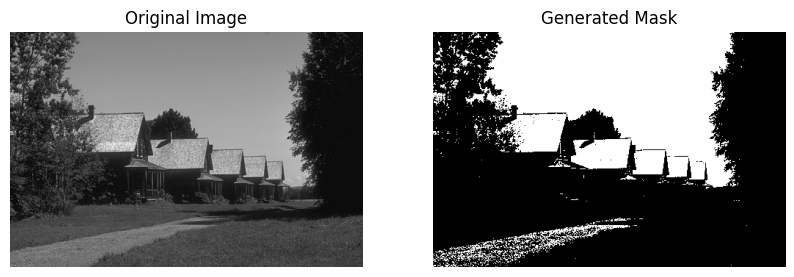

In [31]:
sample_img_path = image_list[100]

img = Image.open(sample_img_path).convert("L")
img_array = np.array(img)

mask_path = os.path.join(
    mask_folder,
    os.path.splitext(os.path.basename(sample_img_path))[0] + "_mask.png"
)
mask = np.array(Image.open(mask_path))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Generated Mask")
plt.axis("off")

plt.show()